### Radial Equilibrium

To validate the axisymmetric solver we need to check the validity of the radial equilibrium equation for swirling flow

$$ 
\frac{dp}{dr} = \frac{\rho u_{\theta}^2}{r}
$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from unsflow.utils.thesis_plots import *
import os 

In [6]:
intputFile = 'Volume_CSV/results.csv'
os.makedirs('Pictures', exist_ok=True)

# Read the first three lines to extract grid sizes
with open(intputFile, 'r') as f:
    ni = int(f.readline().strip().split('=')[1])
    nj = int(f.readline().strip().split('=')[1])
    nk = int(f.readline().strip().split('=')[1])

# Read the rest of the CSV data into a DataFrame
df = pd.read_csv(intputFile, skiprows=3)
data = {}

for field in df.columns:
    data[field] = np.reshape(df[field].values, (ni, nj, nk))



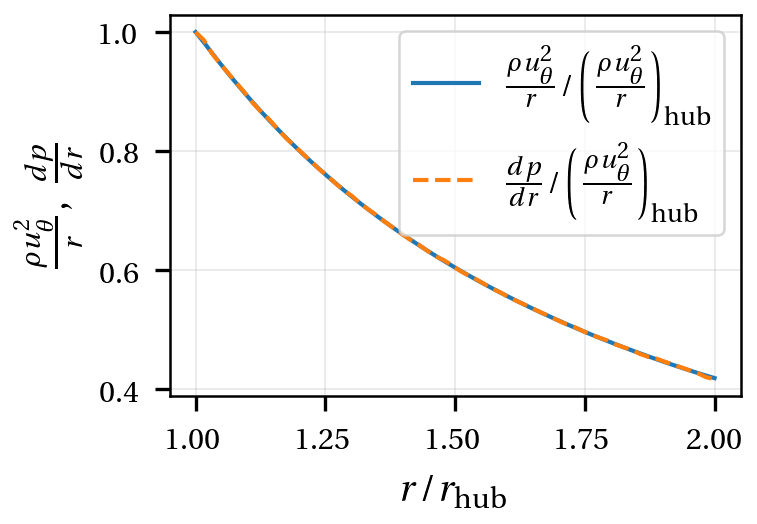

In [21]:
# extract the data at middle axial location
ncheck = ni-1
radius = data['y'][ncheck, :, 0]
utheta = data['Velocity Z'][ncheck, :, 0]
ux = data['Velocity X'][ncheck, :, 0]
density = data['Density'][ncheck, :, 0]
pressure = data['Pressure'][ncheck, :, 0]

dpdr = np.gradient(pressure, radius, edge_order=1)
rhs = density * (utheta**2 / radius)

norm = density[0]*utheta[0]**2/radius[0]

set_thesis_style()
fig, ax = create_figure(fraction=0.5, aspect_ratio=1.45, subplots=(1, 1))
ax.plot(radius/radius.min(), rhs/norm, label=r'$\frac{\rho u_{\theta}^2}{r} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{\rm hub}$')
ax.plot(radius/radius.min(), dpdr/norm, '--', mfc='none', label=r'$\frac{dp}{dr} / \left(\frac{\rho u_{\theta}^2}{r}\right)_{\rm hub}$')
ax.set_xlabel(r'$r/r_{\rm hub}$')
ax.set_ylabel(r'$\frac{\rho u_{\theta}^2}{r}, \ \frac{dp}{dr}$')
ax.legend()
ax.grid(alpha=0.3)
fig.savefig('Pictures/radial_equilibrium_check.pdf')